# 06 — Model Interpretation

SHAP и EBM объяснения для всех обученных моделей:
- **SHAP TreeExplainer** — LightGBM, CatBoost, Random Forest
- **SHAP LinearExplainer** — Logistic Regression
- **Сравнение** топ-10 признаков между моделями
- **EBM** — explain_global() и explain_local()
- **Waterfall plots** для трёх типов заёмщиков

Все графики сохраняются в `reports/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
warnings.filterwarnings('ignore')

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src import config
from src.interpretation import (
    compute_shap_tree,
    compute_shap_linear,
    plot_shap_summary,
    compute_ebm_importances,
)

print(f'shap {shap.__version__}')
print('Ready.')

shap 0.49.1
Ready.


## 1. Загрузка обученных моделей

In [2]:
MODEL_NAMES = ['logreg', 'rf', 'lgbm', 'catboost', 'ebm']

models = {}
for name in MODEL_NAMES:
    path = config.MODELS_DIR / f'{name}.joblib'
    if not path.exists():
        raise FileNotFoundError(f'{path}. Run notebook 04 first.')
    models[name] = joblib.load(path)
    print(f'  [OK] {name:10s}  ({path.stat().st_size / 1024:.0f} KB)')

df_full = pd.read_parquet(config.PROCESSED_FILES['final_train_clean'])
y = df_full[config.TARGET_COL].to_numpy()
X = df_full.drop(columns=[config.TARGET_COL, config.ID_COL])
feat_names = X.columns.tolist()
feat_idx   = {f: i for i, f in enumerate(feat_names)}

print(f'\nData: {X.shape[0]:,} rows x {X.shape[1]} features')

# Fixed subsamples for reproducibility
rng       = np.random.default_rng(config.RANDOM_SEED)
idx_base  = rng.choice(len(X), size=3000, replace=False)
X_sub_3k  = X.iloc[idx_base].reset_index(drop=True)
X_sub_1k  = X.iloc[idx_base[:1000]].reset_index(drop=True)
X_sub_300 = X.iloc[idx_base[:300]].reset_index(drop=True)

print(f'Subsamples ready: 3k / 1k / 300')

  [OK] logreg      (7 KB)
  [OK] rf          (914762 KB)
  [OK] lgbm        (6795 KB)
  [OK] catboost    (1114 KB)
  [OK] ebm         (2885 KB)

Data: 307,511 rows x 209 features
Subsamples ready: 3k / 1k / 300


## 2. SHAP TreeExplainer — LightGBM

Используем кешированный артефакт из ноутбука 04 (`models/lgbm_shap.joblib`, n=5 000).  
Если файл не найден — вычисляем заново на 3 000 строках.

Loaded cached artifact: shap_values=(5000, 209)


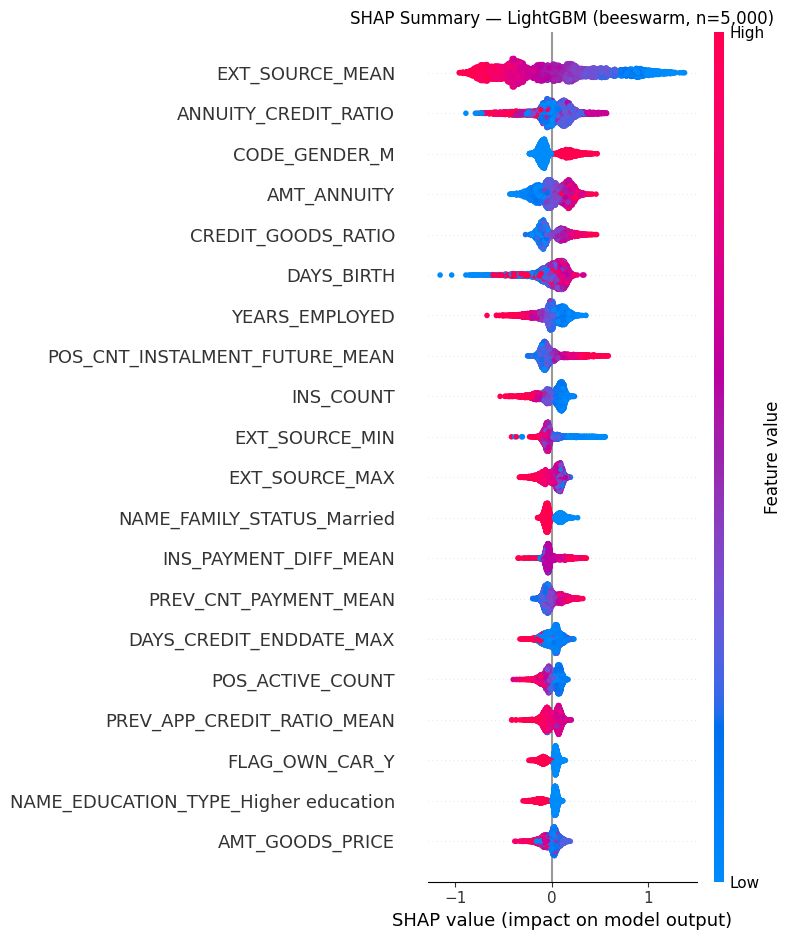

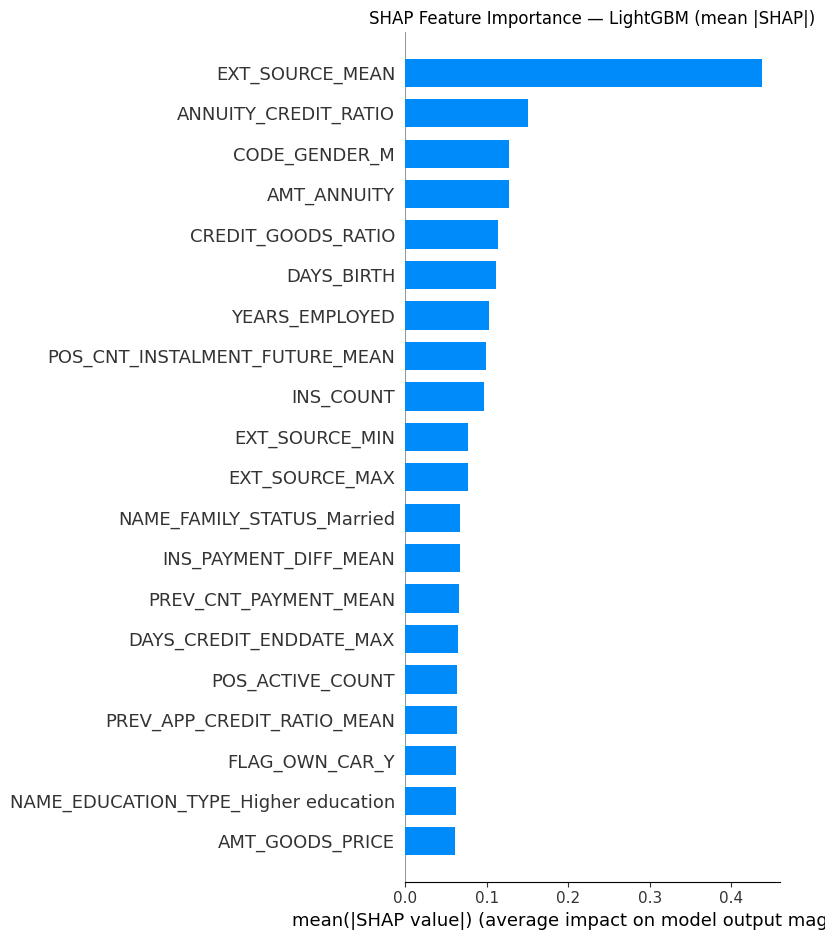

Saved -> reports/interp_shap_lgbm_summary.png
Saved -> reports/interp_shap_lgbm_bar.png


In [3]:
artifact_path = config.MODELS_DIR / 'lgbm_shap.joblib'
if artifact_path.exists():
    artifact     = joblib.load(artifact_path)
    sv_lgbm      = artifact['shap_values']
    X_shap_lgbm  = artifact['X_sample']
    print(f'Loaded cached artifact: shap_values={sv_lgbm.shape}')
else:
    print('Artifact not found — computing fresh (n=3 000)...')
    sv_lgbm     = compute_shap_tree(models['lgbm'], X_sub_3k)
    X_shap_lgbm = X_sub_3k
    print(f'Done: {sv_lgbm.shape}')

plot_shap_summary(
    sv_lgbm, X_shap_lgbm,
    model_name='LightGBM',
    max_display=20,
    save_path_beeswarm=config.REPORTS_DIR / 'interp_shap_lgbm_summary.png',
    save_path_bar=config.REPORTS_DIR / 'interp_shap_lgbm_bar.png',
)
print('Saved -> reports/interp_shap_lgbm_summary.png')
print('Saved -> reports/interp_shap_lgbm_bar.png')

## 3. SHAP TreeExplainer — CatBoost

n = 3 000, ожидаемое время: ~1–2 мин.

Computing SHAP for CatBoost (n=3 000)...
Done: (3000, 209)


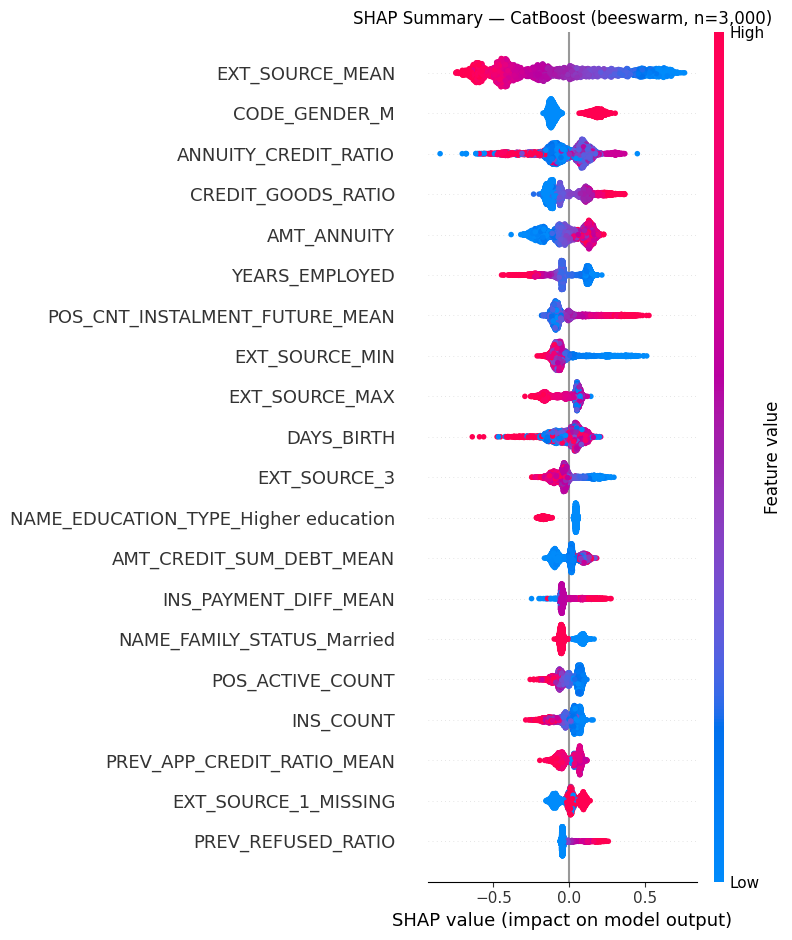

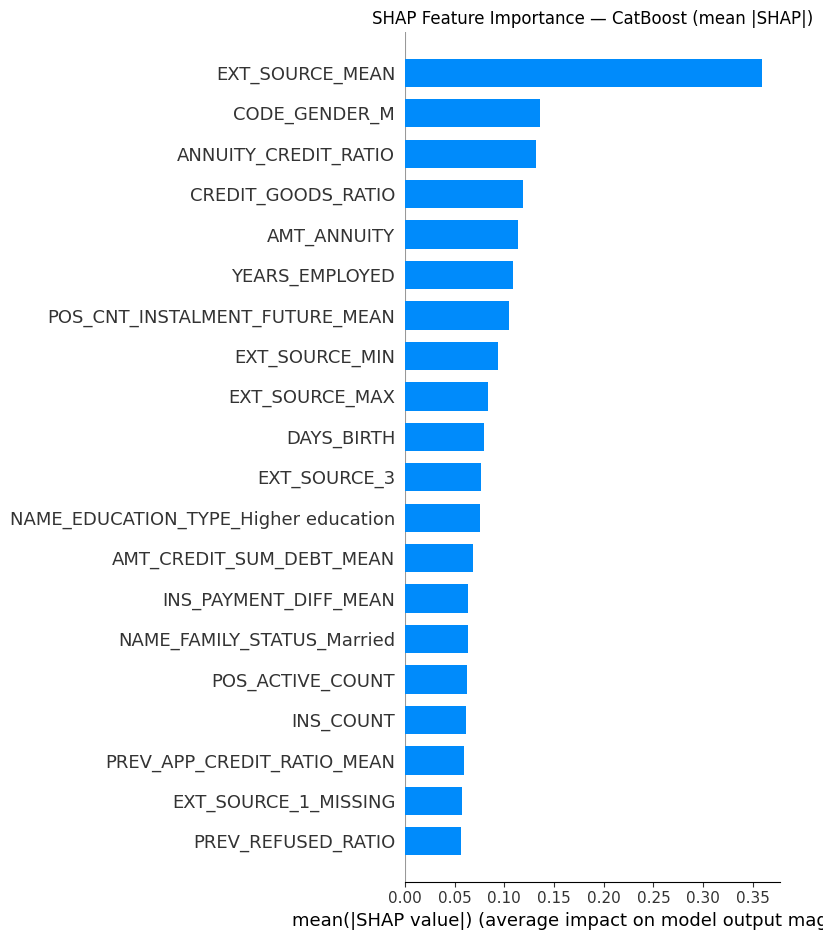

Saved -> reports/interp_shap_catboost_summary.png
Saved -> reports/interp_shap_catboost_bar.png


In [4]:
print('Computing SHAP for CatBoost (n=3 000)...')
sv_catboost = compute_shap_tree(models['catboost'], X_sub_3k)
print(f'Done: {sv_catboost.shape}')

plot_shap_summary(
    sv_catboost, X_sub_3k,
    model_name='CatBoost',
    max_display=20,
    save_path_beeswarm=config.REPORTS_DIR / 'interp_shap_catboost_summary.png',
    save_path_bar=config.REPORTS_DIR / 'interp_shap_catboost_bar.png',
)
print('Saved -> reports/interp_shap_catboost_summary.png')
print('Saved -> reports/interp_shap_catboost_bar.png')

## 4. SHAP TreeExplainer — Random Forest

> **Медленная ячейка** — RF SHAP вычисляется по каждому дереву.  
> n = 300, ожидаемое время: **3–7 мин** (500 деревьев × 209 признаков).

Computing SHAP for Random Forest (n=300) — slow cell...
Done: (300, 209)


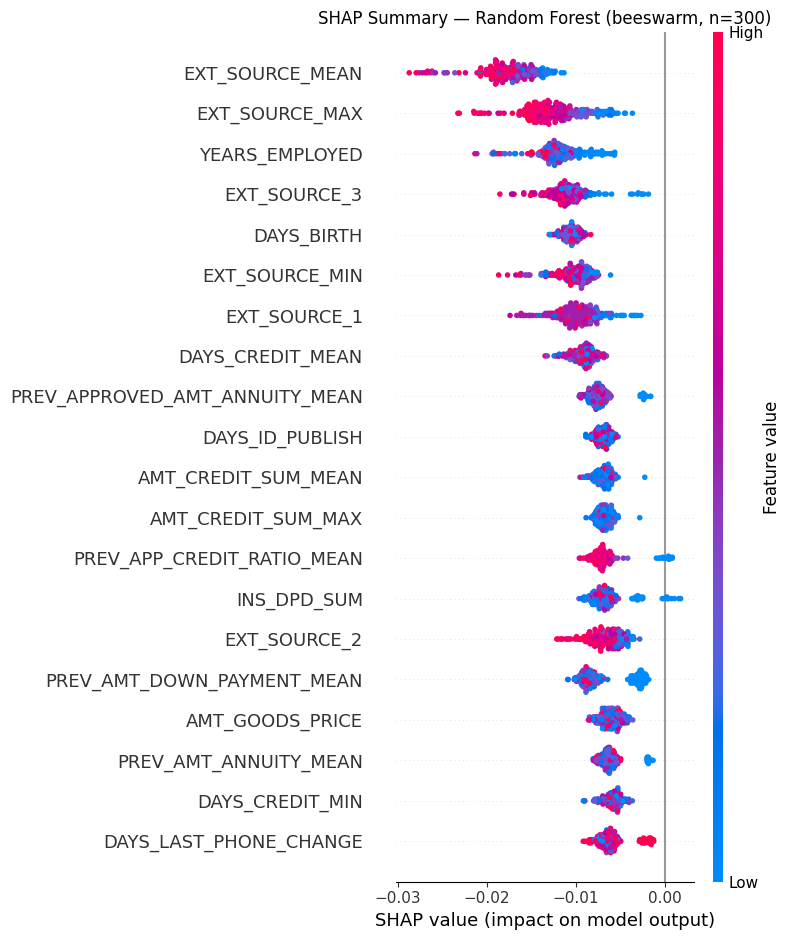

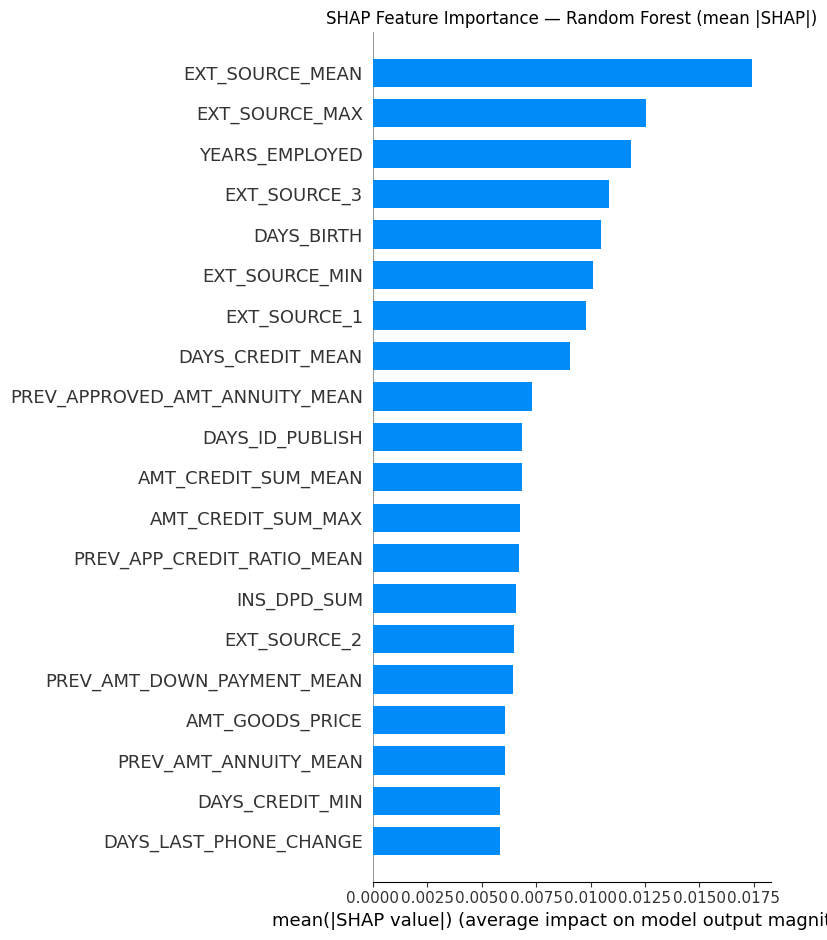

Saved -> reports/interp_shap_rf_summary.png
Saved -> reports/interp_shap_rf_bar.png


In [5]:
print('Computing SHAP for Random Forest (n=300) — slow cell...')
sv_rf = compute_shap_tree(models['rf'], X_sub_300)
print(f'Done: {sv_rf.shape}')

plot_shap_summary(
    sv_rf, X_sub_300,
    model_name='Random Forest',
    max_display=20,
    save_path_beeswarm=config.REPORTS_DIR / 'interp_shap_rf_summary.png',
    save_path_bar=config.REPORTS_DIR / 'interp_shap_rf_bar.png',
)
print('Saved -> reports/interp_shap_rf_summary.png')
print('Saved -> reports/interp_shap_rf_bar.png')

## 5. SHAP LinearExplainer — Logistic Regression

`compute_shap_linear` автоматически применяет `model._scaler` перед вычислением.  
SHAP-значения в масштабированном пространстве признаков, n = 1 000.

Computing SHAP for Logistic Regression (n=1 000, LinearExplainer)...
Done: (1000, 209)


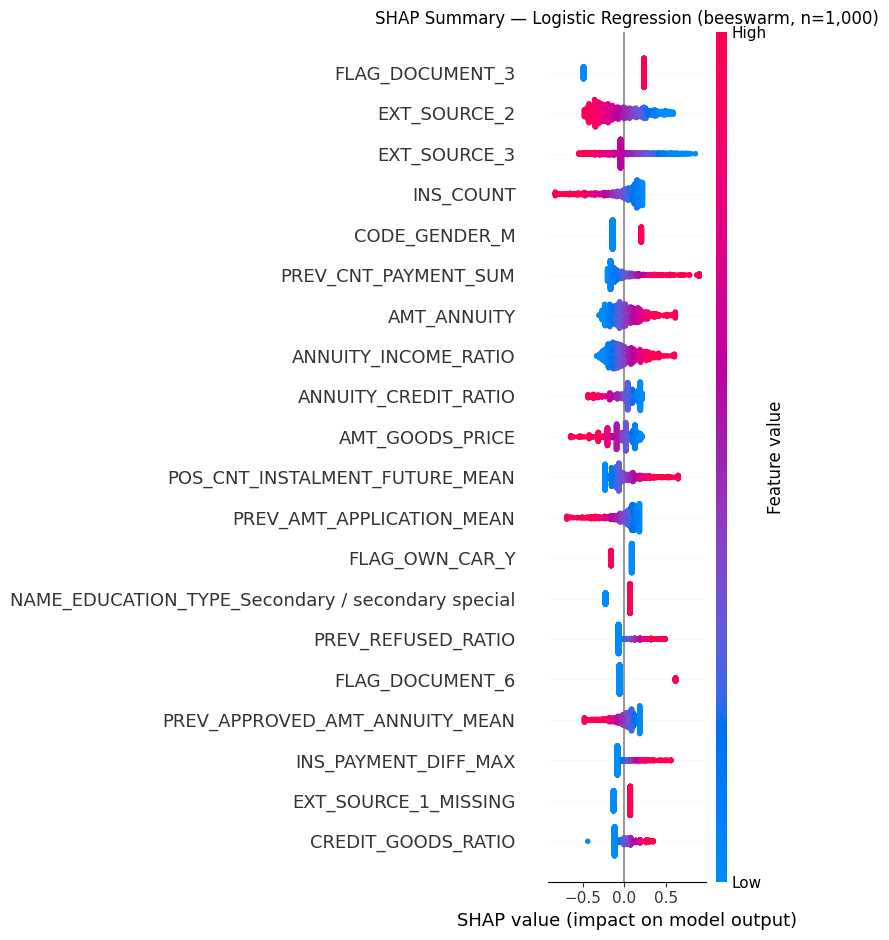

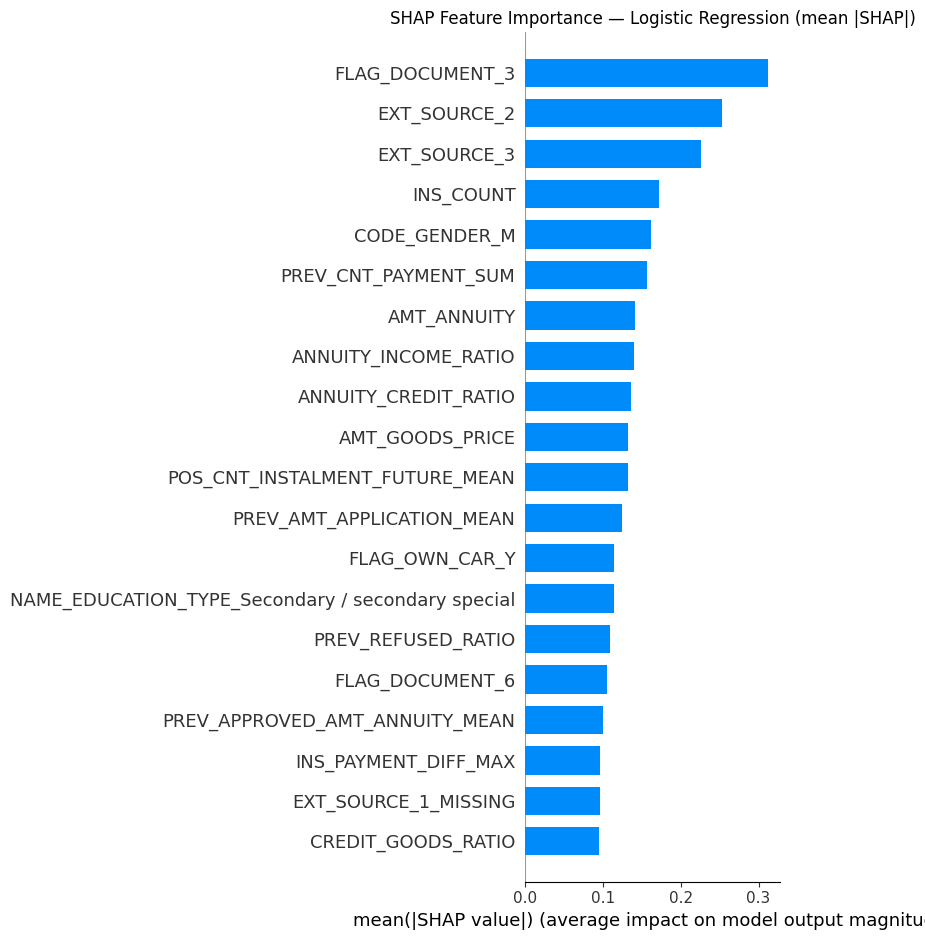

Saved -> reports/interp_shap_logreg_summary.png
Saved -> reports/interp_shap_logreg_bar.png


In [6]:
print('Computing SHAP for Logistic Regression (n=1 000, LinearExplainer)...')
sv_logreg = compute_shap_linear(models['logreg'], X_sub_1k)
print(f'Done: {sv_logreg.shape}')

plot_shap_summary(
    sv_logreg, X_sub_1k,
    model_name='Logistic Regression',
    max_display=20,
    save_path_beeswarm=config.REPORTS_DIR / 'interp_shap_logreg_summary.png',
    save_path_bar=config.REPORTS_DIR / 'interp_shap_logreg_bar.png',
)
print('Saved -> reports/interp_shap_logreg_summary.png')
print('Saved -> reports/interp_shap_logreg_bar.png')

## 6. Сравнение топ-10 признаков между моделями

Тепловая карта: строки = признаки (объединение топ-10 каждой модели),  
столбцы = модели, значения = нормализованный mean |SHAP| (0–1 внутри каждой модели).

LGBM       top-3: ['EXT_SOURCE_MEAN', 'ANNUITY_CREDIT_RATIO', 'CODE_GENDER_M']
CATBOOST   top-3: ['EXT_SOURCE_MEAN', 'CODE_GENDER_M', 'ANNUITY_CREDIT_RATIO']
RF         top-3: ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MAX', 'YEARS_EMPLOYED']
LOGREG     top-3: ['FLAG_DOCUMENT_3', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

Union: 21 unique features


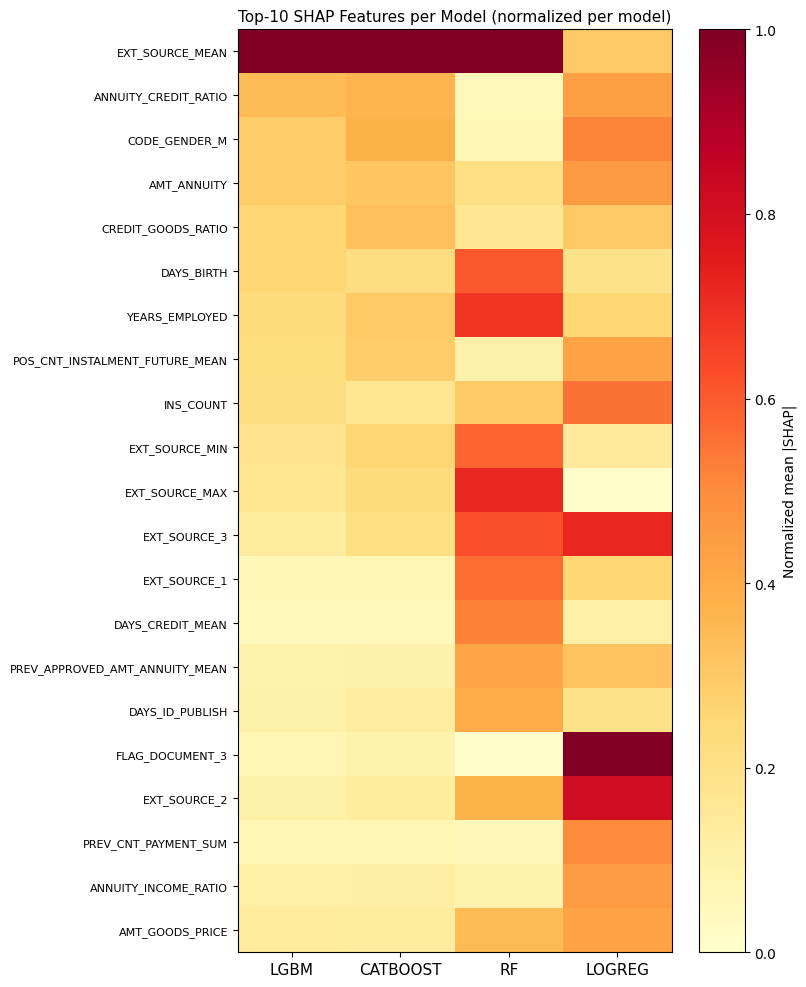

Saved -> reports/interp_shap_comparison.png


In [7]:
all_sv = {
    'lgbm':     sv_lgbm,
    'catboost': sv_catboost,
    'rf':       sv_rf,
    'logreg':   sv_logreg,
}

top10_per_model = {}
for mname, sv in all_sv.items():
    mean_abs = np.abs(sv).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:10]
    top10_per_model[mname] = [feat_names[i] for i in top_idx]
    print(f'{mname.upper():10s} top-3: {top10_per_model[mname][:3]}')

# Union of all top-10, preserving insertion order
union_feats = list(dict.fromkeys(
    f for feats in top10_per_model.values() for f in feats
))
print(f'\nUnion: {len(union_feats)} unique features')

model_order  = ['lgbm', 'catboost', 'rf', 'logreg']
imp_matrix   = np.zeros((len(union_feats), len(model_order)))

for j, mname in enumerate(model_order):
    mean_abs = np.abs(all_sv[mname]).mean(axis=0)
    col_max  = mean_abs.max() + 1e-9
    for i, feat in enumerate(union_feats):
        imp_matrix[i, j] = mean_abs[feat_idx[feat]] / col_max

fig, ax = plt.subplots(figsize=(8, len(union_feats) * 0.38 + 2))
im = ax.imshow(imp_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(model_order)))
ax.set_xticklabels([m.upper() for m in model_order], fontsize=11)
ax.set_yticks(range(len(union_feats)))
ax.set_yticklabels(union_feats, fontsize=8)
plt.colorbar(im, ax=ax, label='Normalized mean |SHAP|')
ax.set_title('Top-10 SHAP Features per Model (normalized per model)', fontsize=11)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / 'interp_shap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> reports/interp_shap_comparison.png')

## 7. EBM — explain_global()

EBM (InterpretML) нативно интерпретируема: каждый признак имеет форм-функцию `f_j(x_j)`.  
Global explanation показывает важность каждого term и попарных взаимодействий.

Computing EBM global explanations...
Top-15 EBM terms:
        term  importance
feature_0109    0.195297
feature_0002    0.193817
feature_0023    0.168161
feature_0022    0.160775
feature_0056    0.156854
feature_0122    0.153349
feature_0003    0.141198
feature_0057    0.120915
feature_0139    0.119673
feature_0117    0.105333
feature_0052    0.103122
feature_0005    0.101518
feature_0055    0.090027
feature_0113    0.087973
feature_0206    0.085025


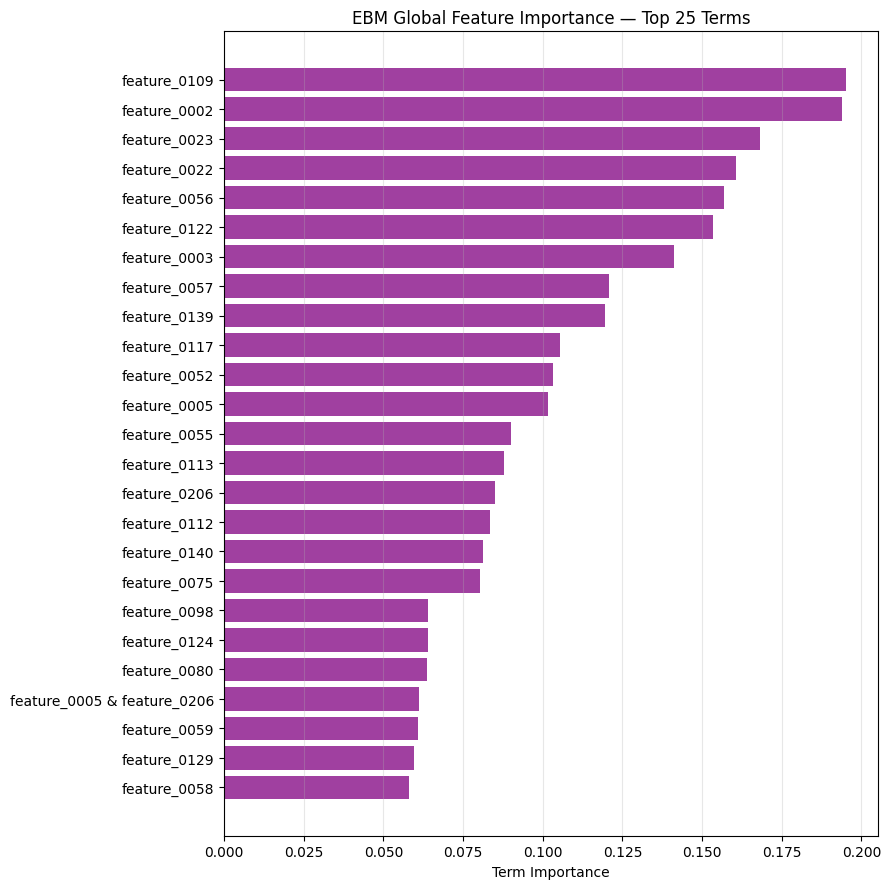

Saved -> reports/interp_ebm_global.png


<!-- http://127.0.0.1:7001/5346564560/ -->

In [8]:
print('Computing EBM global explanations...')
ebm_importances, ebm_global = compute_ebm_importances(models['ebm'])

print('Top-15 EBM terms:')
print(ebm_importances.head(15).to_string(index=False))

top_ebm = ebm_importances.head(25)
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top_ebm['term'][::-1], top_ebm['importance'][::-1], color='purple', alpha=0.75)
ax.set_xlabel('Term Importance')
ax.set_title('EBM Global Feature Importance — Top 25 Terms')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(config.REPORTS_DIR / 'interp_ebm_global.png', dpi=150)
plt.show()
print('Saved -> reports/interp_ebm_global.png')

try:
    from interpret import show
    show(ebm_global)
except Exception as e:
    print(f'[INFO] Interactive dashboard unavailable: {e}')
    print('Tip: open in Jupyter Lab for the full interactive view.')

## 8. Waterfall Plots — три типа заёмщиков

Waterfall plot показывает: как каждый признак **двигает** предсказание от базового значения (E[f(X)])  
к итоговой вероятности. Используется LightGBM — лучшая по AUC модель.

| Заёмщик | Критерий |
|---------|----------|
| Очевидный дефолт | p > 0.80 |
| Очевидный не-дефолт | p < 0.10 |
| Пограничный | 0.45 ≤ p ≤ 0.55 |

In [9]:
# In-sample predictions to locate the three cases
X_arr = X.to_numpy(dtype=np.float32)
proba = models['lgbm'].predict_proba(X_arr)[:, 1]

idx_def    = int(np.where(proba > 0.80)[0][0])
idx_nondef = int(np.where(proba < 0.10)[0][0])
idx_border = int(np.where((proba >= 0.45) & (proba <= 0.55))[0][0])

case_idx = [idx_def, idx_nondef, idx_border]
case_labels = [
    f'Дефолт      (p={proba[idx_def]:.3f}, y={y[idx_def]})',
    f'Не-дефолт   (p={proba[idx_nondef]:.3f}, y={y[idx_nondef]})',
    f'Пограничный (p={proba[idx_border]:.3f}, y={y[idx_border]})',
]

X3 = X.iloc[case_idx].reset_index(drop=True)
y3 = y[case_idx]

print('Три заёмщика:')
for label in case_labels:
    print(f'  {label}')

Три заёмщика:
  Дефолт      (p=0.907, y=1)
  Не-дефолт   (p=0.075, y=0)
  Пограничный (p=0.455, y=0)


Explanation shape: (3, 209)  (3 borrowers x 209 features)


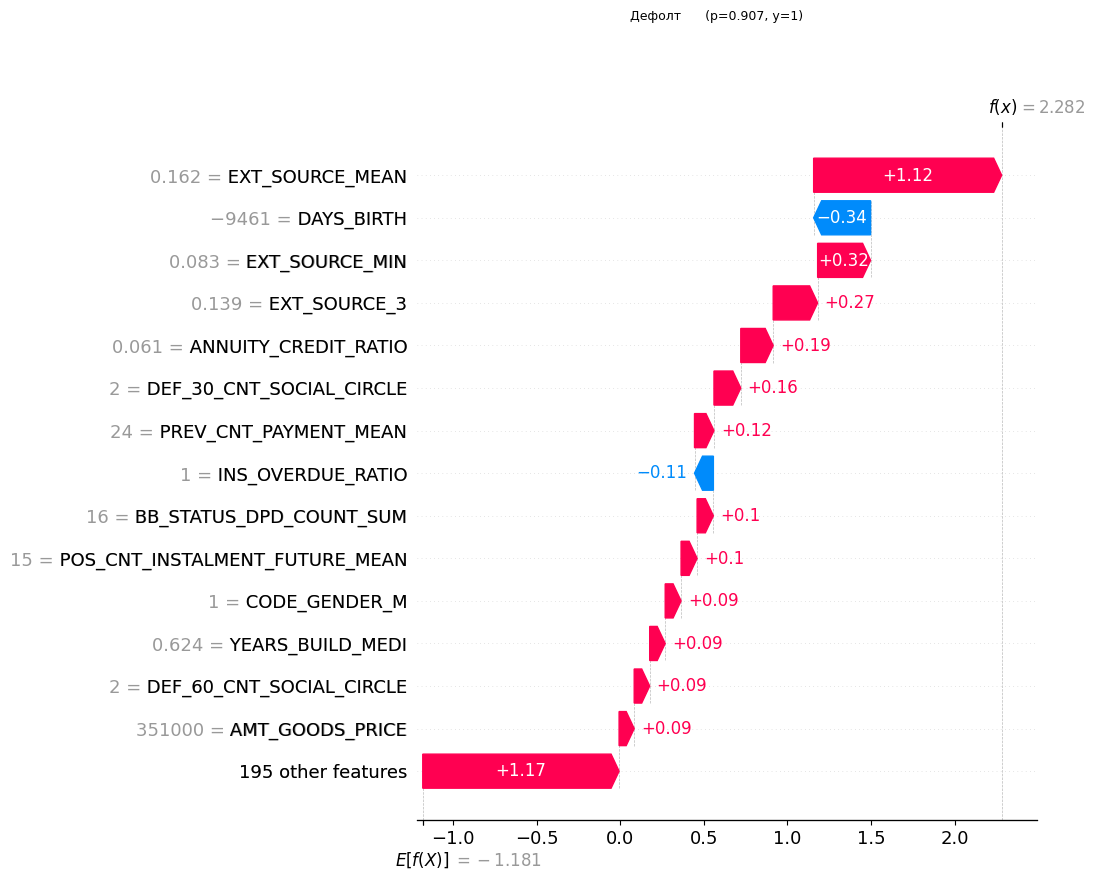

Saved -> reports/interp_waterfall_default.png


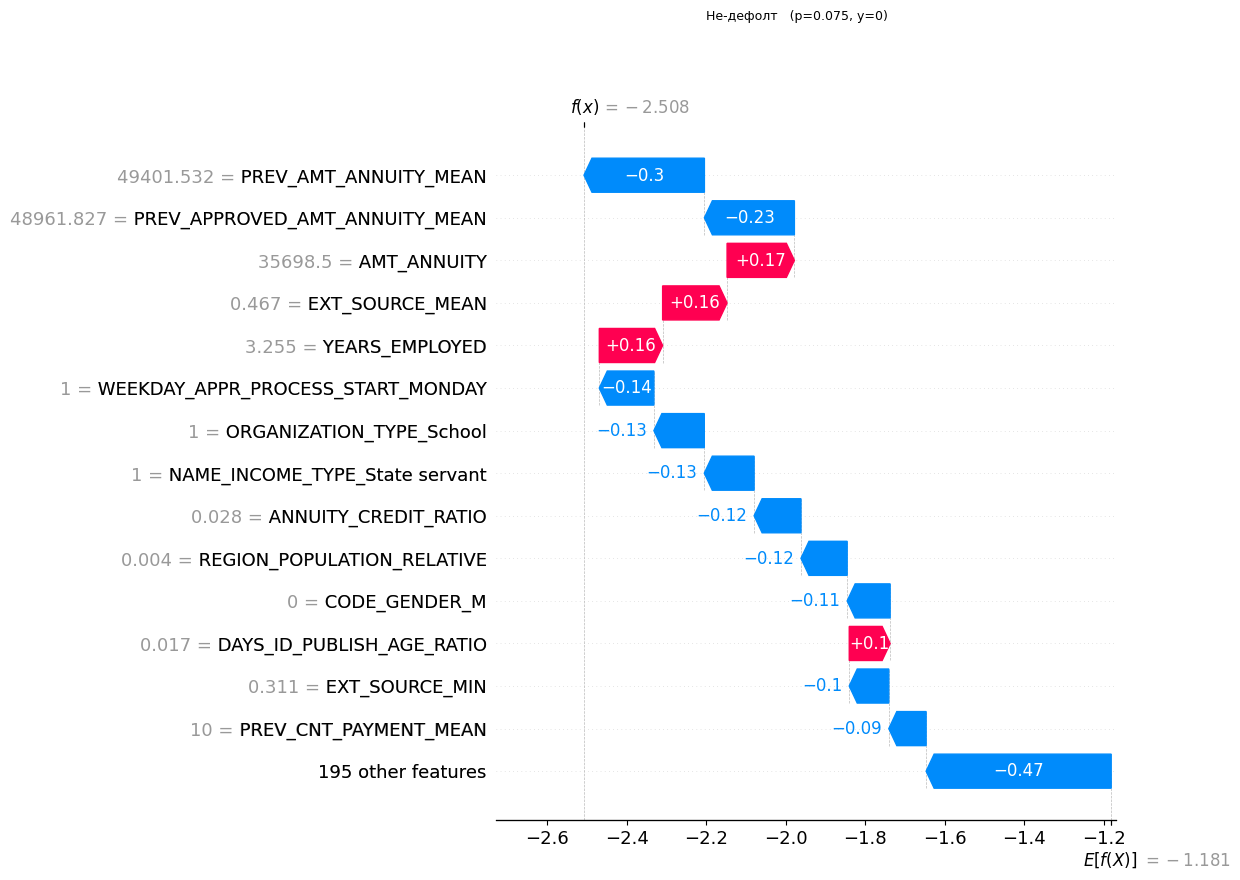

Saved -> reports/interp_waterfall_non_default.png


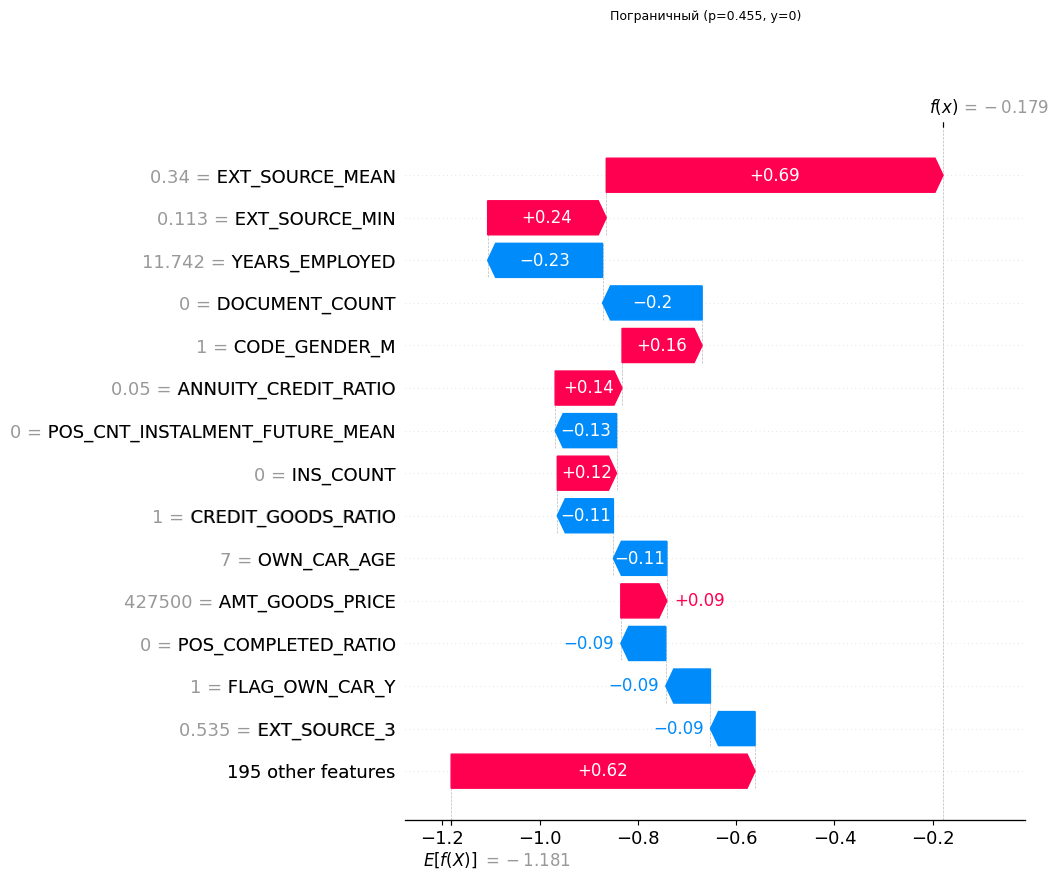

Saved -> reports/interp_waterfall_borderline.png


In [10]:
# SHAP Explanation object for waterfall (new API: explainer(X) not explainer.shap_values(X))
lgbm_explainer = shap.TreeExplainer(models['lgbm'])
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    expl3 = lgbm_explainer(X3, check_additivity=False)

print(f'Explanation shape: {expl3.shape}  (3 borrowers x {expl3.shape[1]} features)')

wf_fnames = ['interp_waterfall_default.png',
             'interp_waterfall_non_default.png',
             'interp_waterfall_borderline.png']

for i in range(3):
    shap.plots.waterfall(expl3[i], max_display=15, show=False)
    plt.gcf().suptitle(case_labels[i], fontsize=9, y=1.01)
    plt.savefig(config.REPORTS_DIR / wf_fnames[i], dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> reports/{wf_fnames[i]}')

## 9. EBM — explain_local() для трёх заёмщиков

EBM local explanation раскладывает предсказание на вклады отдельных term-функций.  
Красный = увеличивает вероятность дефолта, синий = уменьшает.

Computing EBM local explanations...


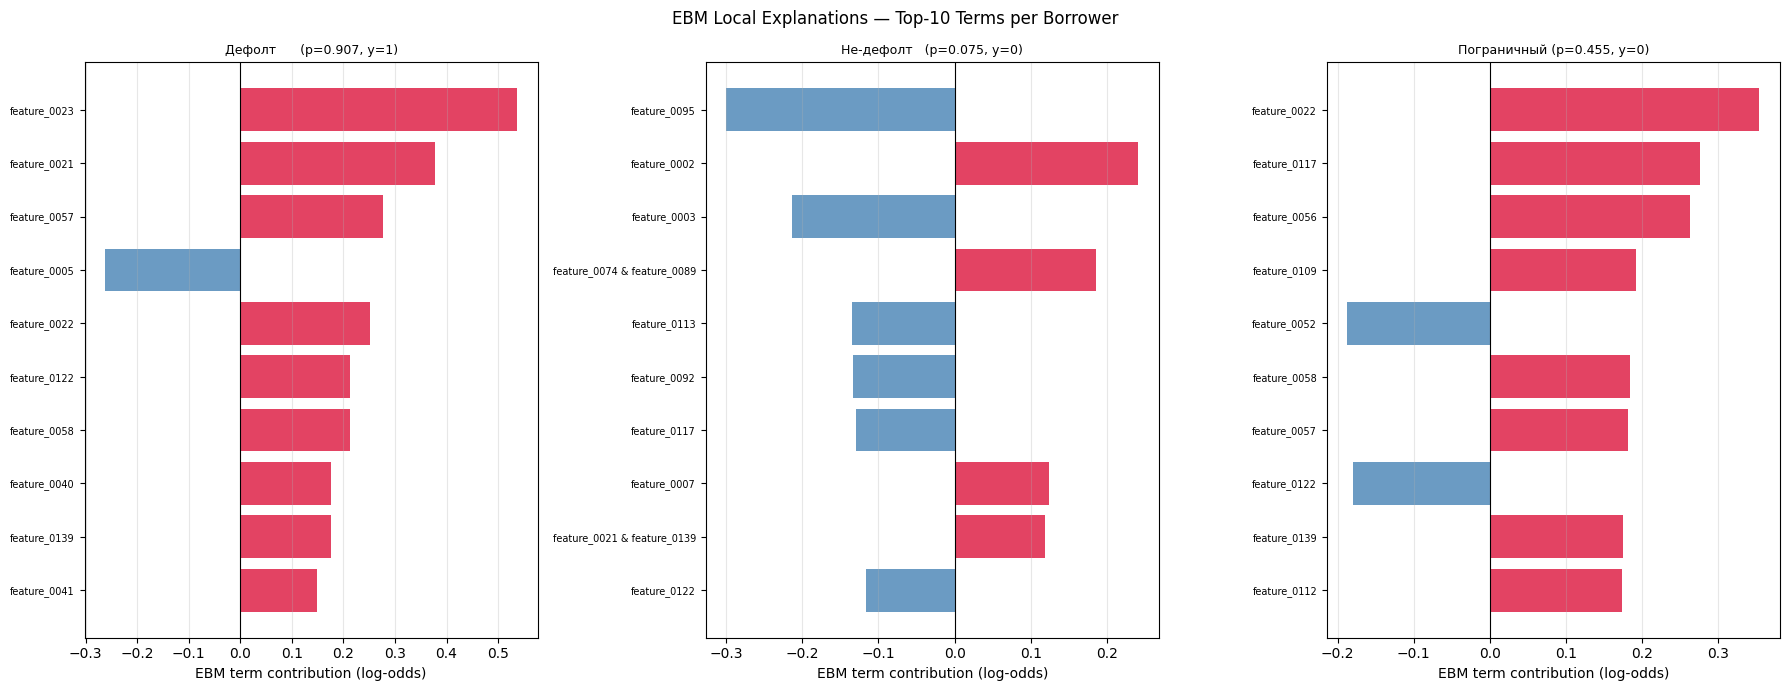

Saved -> reports/interp_ebm_local.png


In [11]:
print('Computing EBM local explanations...')
ebm_local = models['ebm'].explain_local(X3, y3, name='EBM Local')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, (ax, label) in enumerate(zip(axes, case_labels)):
    local_data = ebm_local.data(i)
    names  = local_data.get('names',  [])
    scores = local_data.get('scores', [])

    if not names or not scores:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label, fontsize=9)
        continue

    scores_arr = np.asarray(scores, dtype=float)
    order      = np.argsort(np.abs(scores_arr))[::-1][:10]
    top_names  = [str(names[j])[:30] for j in order]   # truncate long interaction names
    top_scores = scores_arr[order]

    bar_colors = ['crimson' if s > 0 else 'steelblue' for s in top_scores]
    ax.barh(range(len(top_names)), top_scores[::-1], color=bar_colors[::-1], alpha=0.8)
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names[::-1], fontsize=7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('EBM term contribution (log-odds)')
    ax.set_title(label, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('EBM Local Explanations — Top-10 Terms per Borrower', fontsize=12)
plt.tight_layout()
plt.savefig(config.REPORTS_DIR / 'interp_ebm_local.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> reports/interp_ebm_local.png')

In [12]:
# Interactive EBM local dashboard (works in Jupyter Lab / Classic)
try:
    from interpret import show
    show(ebm_local)
except Exception as e:
    print(f'[INFO] Interactive dashboard unavailable in this environment: {e}')
    print('Tip: run `jupyter lab` in terminal and open the notebook there.')

print('\nАртефакты:')
artifacts = [
    'interp_shap_lgbm_summary.png', 'interp_shap_lgbm_bar.png',
    'interp_shap_catboost_summary.png', 'interp_shap_catboost_bar.png',
    'interp_shap_rf_summary.png', 'interp_shap_rf_bar.png',
    'interp_shap_logreg_summary.png', 'interp_shap_logreg_bar.png',
    'interp_shap_comparison.png',
    'interp_ebm_global.png',
    'interp_waterfall_default.png',
    'interp_waterfall_non_default.png',
    'interp_waterfall_borderline.png',
    'interp_ebm_local.png',
]
for fname in artifacts:
    p = config.REPORTS_DIR / fname
    status = 'OK' if p.exists() else 'MISSING'
    print(f'  [{status}] reports/{fname}')

<!-- http://127.0.0.1:7001/5369926656/ -->


Артефакты:
  [OK] reports/interp_shap_lgbm_summary.png
  [OK] reports/interp_shap_lgbm_bar.png
  [OK] reports/interp_shap_catboost_summary.png
  [OK] reports/interp_shap_catboost_bar.png
  [OK] reports/interp_shap_rf_summary.png
  [OK] reports/interp_shap_rf_bar.png
  [OK] reports/interp_shap_logreg_summary.png
  [OK] reports/interp_shap_logreg_bar.png
  [OK] reports/interp_shap_comparison.png
  [OK] reports/interp_ebm_global.png
  [OK] reports/interp_waterfall_default.png
  [OK] reports/interp_waterfall_non_default.png
  [OK] reports/interp_waterfall_borderline.png
  [OK] reports/interp_ebm_local.png
